# Fig: balls

project = ```iP-VAE```, host = ```any```, device = ```any```

**Motivation**: <br>


In [1]:
# HIDE CODE


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, '_IterativeVAE'))
from figures.convergence import plot_convergence
from figures.imgs import plot_weights
from figures.fighelper import *
from main.train import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
device_idx = 1
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:1  ———  host: mach

## Results & Figs dir

In [3]:
pal_models = get_palette_models()

results_dir = pjoin(tmp_dir, 'results_2025-03')
figs_dir = pjoin(fig_base_dir, 'results_2025-03')

os.makedirs(results_dir, exist_ok=True)
os.makedirs(figs_dir, exist_ok=True)

len(os.listdir(results_dir)), len(os.listdir(figs_dir))

(393, 0)

## BALLS dataset

In [4]:
files = [f for f in os.listdir(results_dir) if 'BALLS' in f]
files = sorted(files, key=alphanum_sort_key)

len(files)

213

In [5]:
info_keys = [
    'dataset', 'type', 'latent_act', 'model_str',
    'seq_len', 'kl_beta', 'n_latents',
]

df = collections.defaultdict(list)
for f in tqdm(files):
    is_amortized = 'amort' in f
    try:
        load = np.load(
            pjoin(results_dir, f),
            allow_pickle=True,
        ).item()
    except EOFError:
        print(f"EOFError:\n{f}")
        continue

    info, results = load['info'], load['results']
    info['n_latents'] = info['n_latents'][0]

    # info
    for k in info_keys:
        df[k].append(info.get(k, None))
    df['amort'].append(is_amortized)

    # results
    vals = {
        # '%-zeros_vld': np.mean(results['results_xtract']['vld']['samples'][:, -1, :] == 0.0),
        # 'r2_recon_vld': results['results_xtract']['vld']['r2'][-1],
        # 'r2_untangle_vld': results['r2_zg']['vld'][1000].mean(),
        # 'r2_untangle_vld_0': results['r2_zg']['vld'][1000][0],
        # 'r2_untangle_vld_1': results['r2_zg']['vld'][1000][1],
        # 'r_untangle_vld': results['corr_zg']['vld'][1000].mean(),
        # 'r_untangle_vld_0': results['corr_zg']['vld'][1000][0],
        # 'r_untangle_vld_1': results['corr_zg']['vld'][1000][1],
        'r2_recon_tst': results['results_xtract']['tst']['r2'][-1],
        'r2_untangle_tst': results['r2_zg']['tst'][1000].mean(),
        'r_untangle_tst': results['corr_zg']['tst'][1000].mean(),
        '%-zeros_tst': np.mean(results['results_xtract']['tst']['samples'][:, -1, :] == 0.0),
        'r2_untangle_tst_0': results['r2_zg']['tst'][1000][0],
        'r2_untangle_tst_1': results['r2_zg']['tst'][1000][1],
        'r_untangle_tst_0': results['corr_zg']['tst'][1000][0],
        'r_untangle_tst_1': results['corr_zg']['tst'][1000][1],
    }
    for k, v in vals.items():
        df[k].append(v)
df = pd.DataFrame(df)
df.shape

100%|█████████████████████████████████████████| 213/213 [09:00<00:00,  2.54s/it]


(213, 16)

In [6]:
_df = df.loc[
    (df['seq_len'] == 32) &
    (df['n_latents'] == 96) &
    (df['dataset'] == 'BALLS64')
]

In [8]:
_df

,dataset,type,latent_act,model_str,seq_len,kl_beta,n_latents,amort,r2_recon_tst,r2_untangle_tst,r_untangle_tst,%-zeros_tst,r2_untangle_tst_0,r2_untangle_tst_1,r_untangle_tst_0,r_untangle_tst_1
0,BALLS64,gaussian,relu,gaussian+relu,32,64.0,96,False,0.338011,-0.262225,0.668500,0.880439,-0.410636,-0.113815,0.642906,0.694093
1,BALLS64,gaussian,None,gaussian,32,64.0,96,False,0.966763,0.937432,0.985006,0.000000,0.904382,0.970483,0.980146,0.989865
204,BALLS64,poisson,None,poisson,32,24.0,96,False,0.994131,0.985870,0.994700,0.763405,0.981176,0.990563,0.993747,0.995653
206,BALLS64,poisson,None,poisson,32,48.0,96,False,0.993593,0.942868,0.991724,0.733747,0.982674,0.903062,0.994272,0.989177
209,BALLS64,poisson,None,poisson,32,64.0,96,False,0.993327,0.990167,0.995994,0.751850,0.988992,0.991342,0.995841,0.996147


In [6]:
columns_to_process = [
    'r2_recon_vld', 'r2_recon_tst',
    'r2_untangle_vld', 'r2_untangle_vld_0', 'r2_untangle_vld_1',
    'r2_untangle_tst', 'r2_untangle_tst_0', 'r2_untangle_tst_1',
]
for col in columns_to_process:
    df[col] = df[col].mask(df[col] < 0, np.nan)

df['avg_perf'] = (df['r2_untangle_tst'] + df['r2_recon_tst']) / 2

In [7]:
df

,dataset,type,latent_act,model_str,seq_len,kl_beta,n_latents,amort,%-zeros_vld,%-zeros_tst,r2_recon_vld,r2_recon_tst,r2_untangle_vld,r2_untangle_vld_0,r2_untangle_vld_1,r2_untangle_tst,r2_untangle_tst_0,r2_untangle_tst_1,avg_perf
0,BALLS64,gaussian,relu,gaussian+relu,32,64.0,96,False,0.874103,0.880439,0.513077,0.338011,0.873904,0.876920,0.870889,NaN,NaN,NaN,NaN
1,BALLS64,gaussian,None,gaussian,32,64.0,96,False,0.000000,0.000000,0.976597,0.966763,0.997010,0.997084,0.996937,0.937432,0.904382,0.970483,0.952098
2,BALLS16,poisson,None,poisson,8,4.0,8,False,0.179037,0.160960,0.722468,0.536938,0.941976,0.927955,0.955997,0.637630,0.536667,0.738592,0.587284
3,BALLS16,poisson,None,poisson,8,4.0,16,False,0.396294,0.448500,0.836406,0.844588,0.989995,0.991556,0.988433,0.937603,0.939815,0.935391,0.891095
4,BALLS16,poisson,None,poisson,8,4.0,24,False,0.590977,0.567368,0.910668,0.910017,0.994232,0.994898,0.993566,0.962905,0.967815,0.957995,0.936461
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
208,BALLS64,poisson,None,poisson,32,64.0,64,False,0.649978,0.626374,0.991294,0.991112,0.998350,0.998530,0.998170,0.989804,0.990533,0.989074,0.990458
209,BALLS64,poisson,None,poisson,32,64.0,96,False,0.725450,0.751850,0.993546,0.993327,0.998713,0.998739,0.998687,0.990167,0.988992,0.991342,0.991747
210,BALLS64,poisson,None,poisson,8,8.0,32,False,0.630808,0.590924,0.969510,0.969814,0.997763,0.998181,0.997346,0.983284,0.986977,0.979591,0.976549
211,BALLS64,poisson,None,poisson,8,4.0,256,False,0.882506,0.869603,0.992897,NaN,0.997898,0.997961,0.997836,NaN,NaN,NaN,NaN


In [8]:
df['r2_untangle_tst'].max(), df['r2_recon_tst'].max()

(0.9901668550934274, 0.994131326675415)

In [9]:
df

,dataset,type,latent_act,model_str,seq_len,kl_beta,n_latents,amort,%-zeros_vld,%-zeros_tst,r2_recon_vld,r2_recon_tst,r2_untangle_vld,r2_untangle_vld_0,r2_untangle_vld_1,r2_untangle_tst,r2_untangle_tst_0,r2_untangle_tst_1,avg_perf
0,BALLS64,gaussian,relu,gaussian+relu,32,64.0,96,False,0.874103,0.880439,0.513077,0.338011,0.873904,0.876920,0.870889,NaN,NaN,NaN,NaN
1,BALLS64,gaussian,None,gaussian,32,64.0,96,False,0.000000,0.000000,0.976597,0.966763,0.997010,0.997084,0.996937,0.937432,0.904382,0.970483,0.952098
2,BALLS16,poisson,None,poisson,8,4.0,8,False,0.179037,0.160960,0.722468,0.536938,0.941976,0.927955,0.955997,0.637630,0.536667,0.738592,0.587284
3,BALLS16,poisson,None,poisson,8,4.0,16,False,0.396294,0.448500,0.836406,0.844588,0.989995,0.991556,0.988433,0.937603,0.939815,0.935391,0.891095
4,BALLS16,poisson,None,poisson,8,4.0,24,False,0.590977,0.567368,0.910668,0.910017,0.994232,0.994898,0.993566,0.962905,0.967815,0.957995,0.936461
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
208,BALLS64,poisson,None,poisson,32,64.0,64,False,0.649978,0.626374,0.991294,0.991112,0.998350,0.998530,0.998170,0.989804,0.990533,0.989074,0.990458
209,BALLS64,poisson,None,poisson,32,64.0,96,False,0.725450,0.751850,0.993546,0.993327,0.998713,0.998739,0.998687,0.990167,0.988992,0.991342,0.991747
210,BALLS64,poisson,None,poisson,8,8.0,32,False,0.630808,0.590924,0.969510,0.969814,0.997763,0.998181,0.997346,0.983284,0.986977,0.979591,0.976549
211,BALLS64,poisson,None,poisson,8,4.0,256,False,0.882506,0.869603,0.992897,NaN,0.997898,0.997961,0.997836,NaN,NaN,NaN,NaN


<Axes: xlabel='n_latents', ylabel='r2_untangle_tst'>

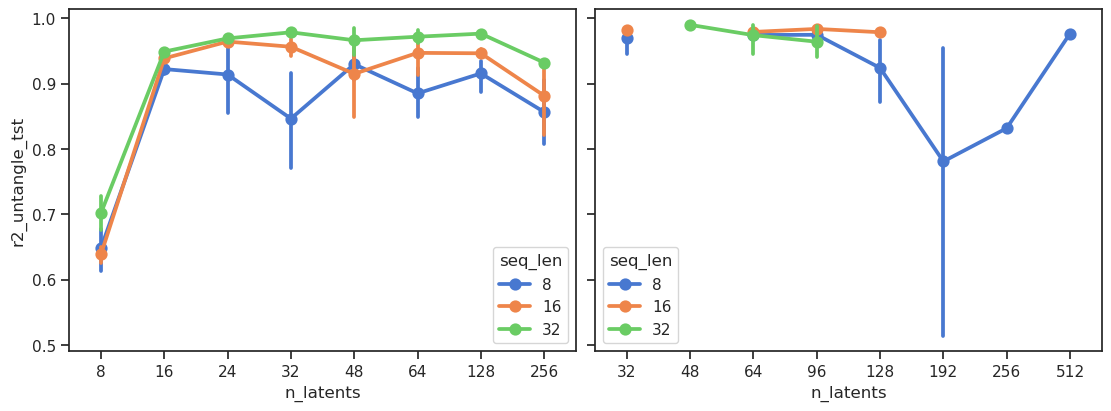

In [10]:
fig, axes = create_figure(1, 2, (11, 4), sharey='all')

_df = df.loc[df['dataset'] == 'BALLS16']
sns.pointplot(data=_df, x='n_latents', hue='seq_len', palette='muted', y='r2_untangle_tst', ax=axes[0])

_df = df.loc[df['dataset'] == 'BALLS64']
sns.pointplot(data=_df, x='n_latents', hue='seq_len', palette='muted', y='r2_untangle_tst', ax=axes[1])

#  ax.set(ylim=(0, 1))

In [13]:
_df = df.loc[df['dataset'] == 'BALLS64']

In [14]:
df.sort_values(by='avg_perf', ascending=False)[:20]

,dataset,type,latent_act,model_str,seq_len,kl_beta,n_latents,amort,%-zeros_vld,%-zeros_tst,r2_recon_vld,r2_recon_tst,r2_untangle_vld,r2_untangle_vld_0,r2_untangle_vld_1,r2_untangle_tst,r2_untangle_tst_0,r2_untangle_tst_1,avg_perf
209,BALLS64,poisson,None,poisson,32,64.0,96,False,0.725450,0.751850,0.993546,0.993327,0.998713,0.998739,0.998687,0.990167,0.988992,0.991342,0.991747
208,BALLS64,poisson,None,poisson,32,64.0,64,False,0.649978,0.626374,0.991294,0.991112,0.998350,0.998530,0.998170,0.989804,0.990533,0.989074,0.990458
203,BALLS64,poisson,None,poisson,32,24.0,64,False,0.653123,0.664990,0.993813,0.992571,0.998423,0.998407,0.998440,0.987884,0.988625,0.987143,0.990227
204,BALLS64,poisson,None,poisson,32,24.0,96,False,0.742707,0.763405,0.995165,0.994131,0.998745,0.998719,0.998772,0.985870,0.981176,0.990563,0.990000
182,BALLS64,poisson,None,poisson,16,8.0,64,False,0.623729,0.619955,0.992346,0.991346,0.997785,0.997680,0.997890,0.986831,0.987326,0.986335,0.989088
188,BALLS64,poisson,None,poisson,16,16.0,96,False,0.766865,0.748902,0.992864,0.991853,0.997904,0.997823,0.997984,0.984894,0.983428,0.986359,0.988374
184,BALLS64,poisson,None,poisson,16,12.0,96,False,0.766661,0.756925,0.991910,0.991287,0.998218,0.998232,0.998204,0.984741,0.985825,0.983658,0.988014
207,BALLS64,poisson,None,poisson,32,64.0,48,False,0.635566,0.637222,0.987000,0.985912,0.998443,0.998121,0.998764,0.989842,0.989140,0.990543,0.987877
192,BALLS64,poisson,None,poisson,16,24.0,96,False,0.772927,0.776578,0.991924,0.990936,0.997784,0.997694,0.997873,0.983512,0.987287,0.979737,0.987224
183,BALLS64,poisson,None,poisson,16,12.0,64,False,0.660209,0.654875,0.991607,0.990487,0.997698,0.997644,0.997753,0.982977,0.980906,0.985048,0.986732


In [16]:
_df

,dataset,type,latent_act,model_str,seq_len,kl_beta,n_latents,amort,%-zeros_vld,%-zeros_tst,r2_recon_vld,r2_recon_tst,r2_untangle_vld,r2_untangle_vld_0,r2_untangle_vld_1,r2_untangle_tst,r2_untangle_tst_0,r2_untangle_tst_1,avg_perf
0,BALLS64,gaussian,relu,gaussian+relu,32,64.0,96,False,0.874103,0.880439,0.513077,0.338011,0.873904,0.876920,0.870889,NaN,NaN,NaN,NaN
1,BALLS64,gaussian,None,gaussian,32,64.0,96,False,0.000000,0.000000,0.976597,0.966763,0.997010,0.997084,0.996937,0.937432,0.904382,0.970483,0.952098
204,BALLS64,poisson,None,poisson,32,24.0,96,False,0.742707,0.763405,0.995165,0.994131,0.998745,0.998719,0.998772,0.985870,0.981176,0.990563,0.990000
206,BALLS64,poisson,None,poisson,32,48.0,96,False,0.726489,0.733747,0.994015,0.993593,0.998597,0.998548,0.998647,0.942868,0.982674,0.903062,0.968230
209,BALLS64,poisson,None,poisson,32,64.0,96,False,0.725450,0.751850,0.993546,0.993327,0.998713,0.998739,0.998687,0.990167,0.988992,0.991342,0.991747


In [ ]:
t-32_b-64_k-96